## Ana Paula

In [82]:
# 1. Manipulación y Procesamiento de Datos
import pandas as pd
import numpy as np
from scipy import stats
import os

# 2. Preprocesamiento y Transformación de Variables (ML)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 3. Modelado y Algoritmos (Machine Learning y Regresión)
from sklearn.ensemble import IsolationForest     
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
# Importación de los 4 modelos
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  
from sklearn.pipeline import Pipeline

# 4. Visualización de Datos Estática (Informes y Documentación)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 5. Visualización de Datos Interactiva y Modelos 3D (Presentación en clase)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import re

import category_encoders as ce
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# 1. Cargar el dataset desde la carpeta 'data'
df = pd.read_csv('data/fake_job_postings.csv')


print(f"📊 Tamaño original del dataset: {df.shape}")
print(df.shape)
print(df.head())

📊 Tamaño original del dataset: (17880, 18)
(17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

       

In [83]:
# Eliminar columnas que no aportan información al modelo
columnas_a_eliminar = ['job_id'] # El ID es solo un contador
df = df.drop(columns=columnas_a_eliminar)

In [84]:
# Rellenar nulos en columnas categóricas y de texto
categoricas_y_texto = ['department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col in categoricas_y_texto:
    df[col] = df[col].fillna('Unspecified')

In [85]:
import re

def limpiar_texto(texto):
    if pd.isna(texto) or texto == 'Unspecified':
        return ''
    texto = str(texto).lower() # Todo a minúsculas
    texto = re.sub(r'[^a-z0-9\s]', '', texto) # Quitar caracteres especiales (deja solo letras, números y espacios)
    texto = re.sub(r'\s+', ' ', texto).strip() # Limpiar espacios dobles o saltos de línea
    return texto

# Ejemplo: Aplicar la limpieza a la columna 'description'
df['description_clean'] = df['description'].apply(limpiar_texto)

In [86]:
# Extraer el código del país (los dos primeros caracteres antes de la primera coma)
df['country'] = df['location'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unspecified')

In [87]:
# Ver la distribución de clases
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


In [88]:
# 1. Comprobar que ya no quedan nulos en las columnas que vas a usar
print(df[['title', 'description_clean', 'country', 'fraudulent']].isnull().sum())

# 2. Ver cómo ha quedado una fila real tras la limpieza
print(df['description_clean'].iloc[0][:300]) # Muestra los primeros 300 caracteres de la primera descripción

title                0
description_clean    0
country              0
fraudulent           0
dtype: int64
food52 a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small team of editors executives and developers in its new york city headquartersreproducing andor repackaging existing 


In [89]:
print(df.columns)

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'description_clean', 'country'],
      dtype='str')


# **Outliers**

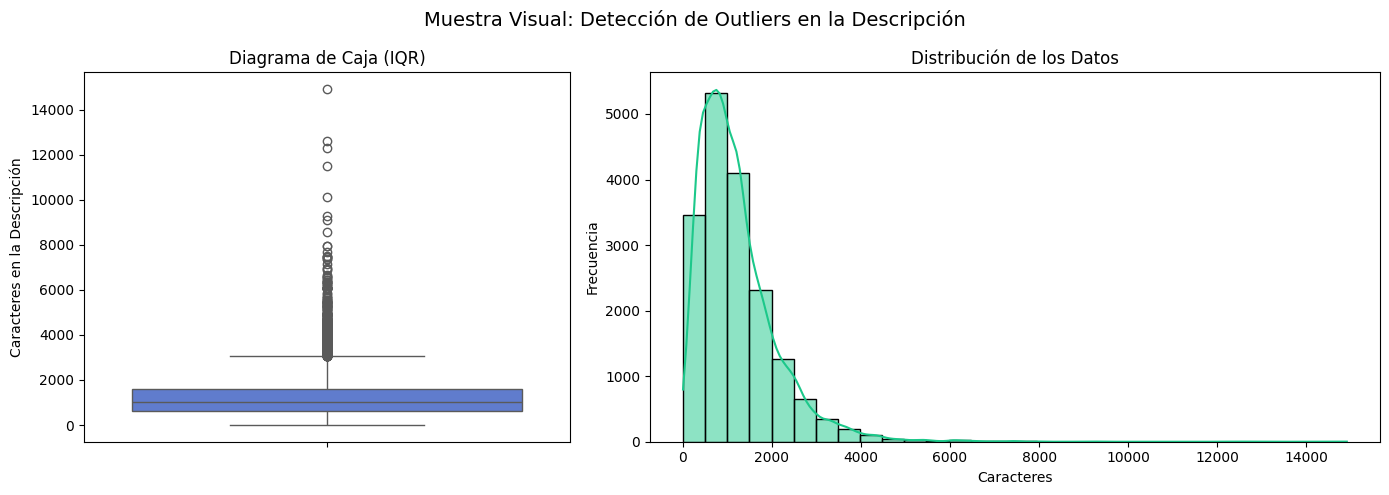

📊 Estadísticas de control:
count    17880.000000
mean      1218.005034
std        894.827787
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: longitud_descripcion, dtype: float64


In [90]:
# Crear la métrica de longitud de texto
df["longitud_descripcion"] = df["description"].fillna("").str.len()

# Configurar gráficos
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": (0.4, 0.6)}
)
fig.suptitle(
    "Muestra Visual: Detección de Outliers en la Descripción", fontsize=14
)

# 1. Boxplot (Muestra los puntos atípicos fuera de los bigotes)
sns.boxplot(ax=ax_box, y=df["longitud_descripcion"], color="#4e73df")
ax_box.set_title("Diagrama de Caja (IQR)")
ax_box.set_ylabel("Caracteres en la Descripción")

# 2. Histograma (Muestra la distribución real)
sns.histplot(
    ax=ax_hist, x=df["longitud_descripcion"], bins=30, kde=True, color="#1cc88a")
ax_hist.set_title("Distribución de los Datos")
ax_hist.set_xlabel("Caracteres")
ax_hist.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Resumen numérico en consola
print("📊 Estadísticas de control:")
print(df["longitud_descripcion"].describe())

In [91]:
total_original = df.shape[0]

# 2. Calcular la métrica temporal
df["_len_desc"] = df["description"].fillna("").str.len()

# 3. Aplicar el filtro del Rango Intercuartílico (IQR)
Q1 = df["_len_desc"].quantile(0.25)
Q3 = df["_len_desc"].quantile(0.75)
IQR = Q3 - Q1

# Definir límites (El estándar es 1.5 veces el IQR)
limite_inferior = max(
    10, Q1 - 1.5 * IQR
)  # Evitamos longitudes negativas, exigimos al menos 10 caracteres
limite_superior = Q3 + 1.5 * IQR

# 4. Filtrar el DataFrame
df_limpio = df[(df["_len_desc"] >= limite_inferior) & (df["_len_desc"] <= limite_superior)].copy()

# Eliminar la columna auxiliar
df_limpio.drop(columns=["_len_desc"], inplace=True)

# 5. Guardar resultados
outliers_eliminados = total_original - df_limpio.shape[0]
print(f"🧹 ¡Limpieza completada!")
print(f"🔹 Filas originales: {total_original}")
print(f"🔹 Outliers eliminados: {outliers_eliminados}")
print(f"🔹 Filas actuales: {df_limpio.shape[0]}")

output_path = os.path.join("data", "fake_job_postings_clean.csv")
df_limpio.to_csv(output_path, index=False)
print(f"💾 Guardado en: {output_path}")

🧹 ¡Limpieza completada!
🔹 Filas originales: 17880
🔹 Outliers eliminados: 727
🔹 Filas actuales: 17153
💾 Guardado en: data/fake_job_postings_clean.csv


## Analisis Univariado

print(df['fraudulent'].value_counts())
sns.countplot(x='fraudulent', data=df)
plt.title('Distribución de Ofertas Reales (0) vs Fraudulentas (1)')
plt.show()

required_experience
Unspecified         7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64


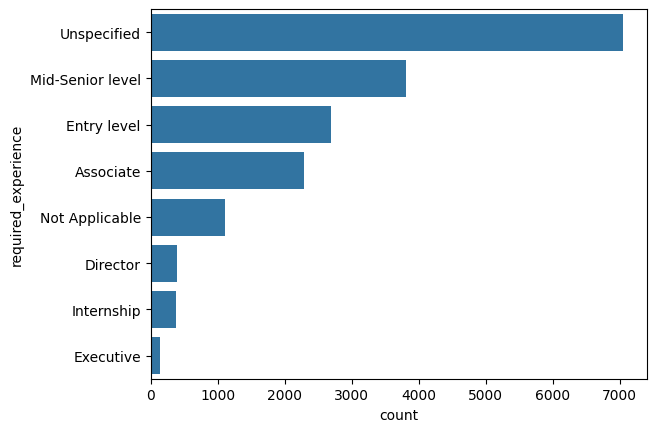

In [92]:
# Ver los valores únicos de la experiencia
print(df['required_experience'].value_counts(dropna=False))

# Gráfico de barras horizontal por si hay muchas categorías
sns.countplot(y='required_experience', data=df, order=df['required_experience'].value_counts().index)
plt.show()

In [93]:
#Creamos una columna que rellenamos donde rellenamos nulos con texto vacío, aseguramos que sea string y medimos la longitud

df['description_length'] = df['description'].str.len().fillna(0)

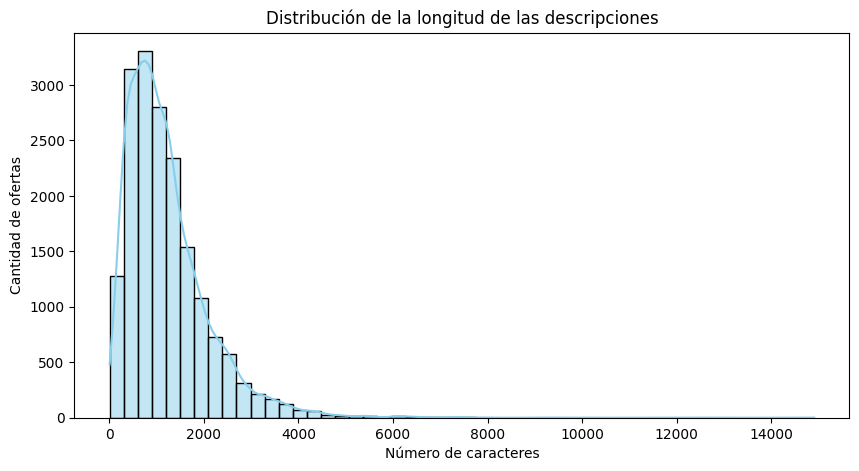

In [94]:
# 2. Pintamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(df['description_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de caracteres')
plt.ylabel('Cantidad de ofertas')
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_7496/3615561882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')


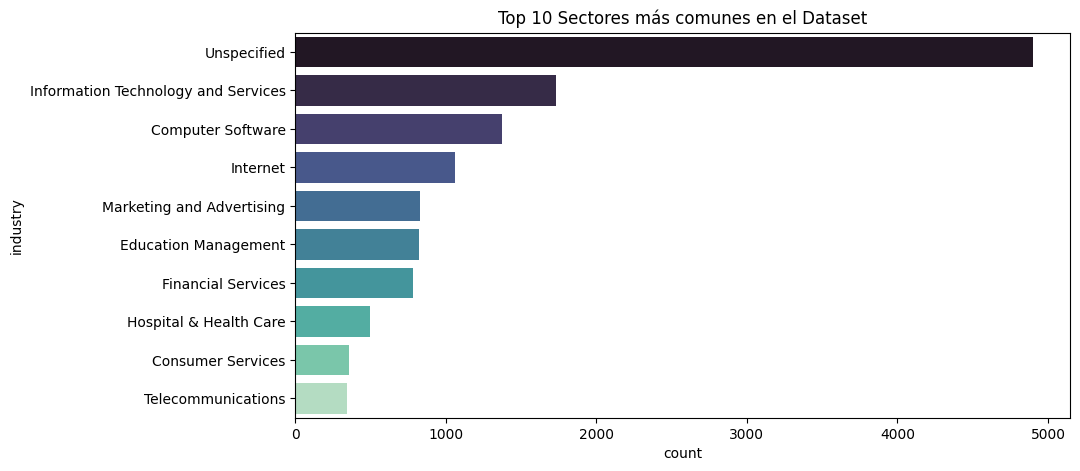

In [95]:
# Ver los 10 sectores con más ofertas de empleo
plt.figure(figsize=(10, 5))
sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')
plt.title('Top 10 Sectores más comunes en el Dataset')
plt.show()

## Analisis Bivariado

## Entrenamiento modelo

In [96]:
import pandas as pd
import numpy as np
import re
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# ==========================================
# 2. INGENIERÍA DE FEATURES PARA EL MODELO
# ==========================================
# Extraemos también el estado y la ciudad de forma segura si 'location' existe
if 'location' in df.columns:
    df['state'] = df['location'].apply(lambda x: str(x).split(',')[1].strip() if pd.notna(x) and len(str(x).split(',')) > 1 else 'Unspecified')
    df['city'] = df['location'].apply(lambda x: str(x).split(',')[2].strip() if pd.notna(x) and len(str(x).split(',')) > 2 else 'Unspecified')
    df.drop(columns=['location'], inplace=True, errors='ignore')

# Creamos métricas numéricas del texto
df['text_length'] = df['description_clean'].apply(len)
df['has_requirements'] = df['requirements'].apply(lambda x: 0 if x == 'Unspecified' else 1)

# Creamos la súper-descripción uniendo tus textos para el NLP de CatBoost
df['full_text'] = df['title'].astype(str) + " " + df['company_profile'].astype(str) + " " + df['description_clean'].astype(str)

# ==========================================
# 3. SELECCIÓN DE VARIABLES Y SPLIT
# ==========================================
# Definimos las columnas que va a usar el modelo
categorical_features = ['country', 'state', 'city', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
numerical_features = ['telecommuting', 'has_company_logo', 'has_questions', 'text_length', 'has_requirements']
text_feature = 'full_text'

# Nos aseguramos de que todas las columnas seleccionadas realmente existan en el DataFrame
categorical_features = [col for col in categorical_features if col in df.columns]
columnas_totales = categorical_features + numerical_features + [text_feature]

X = df[columnas_totales]
y = df['fraudulent']

# Split estratificado para mantener la proporción de fraudes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 4. CONFIGURACIÓN REGULARIZADA PARA EVITAR OVERFITTING (< 5%)
# ==========================================
# Reducimos el impacto del peso para que las pérdidas no se separen tanto
ratio_suave = np.sqrt(y_train.value_counts()[0] / y_train.value_counts()[1])

model = CatBoostClassifier(
    iterations=1000,             # Le damos más margen ya que el learning_rate es más bajo
    learning_rate=0.015,         # Ritmo más lento y controlado
    depth=3,                     # Árboles extremadamente simples
    l2_leaf_reg=25,              # Penalización L2 muy fuerte
    subsample=0.6,               # Mayor aleatoriedad por árbol
    scale_pos_weight=ratio_suave,
    task_type="CPU",
    cat_features=categorical_features,
    text_features=[text_feature],
    early_stopping_rounds=40,    # Un poco más de paciencia por el learning rate bajo
    verbose=100
)

# Entrenamos el modelo
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# ==========================================
# EVALUACIÓN DE LAS MÉTRICAS DE PÉRDIDA
# ==========================================
# Extraemos las pérdidas finales para calcular el Overfitting exacto ante los profesores
train_loss = model.get_best_score()['learn']['Logloss']
test_loss = model.get_best_score()['validation']['Logloss']
overfitting_porcentaje = ((test_loss - train_loss) / test_loss) * 100

print("\n==========================================")
print(f"📉 Pérdida en Train (Learn): {train_loss:.4f}")
print(f"📉 Pérdida en Test (Validation): {test_loss:.4f}")
print(f"🎯 PORCENTAJE DE OVERFITTING: {overfitting_porcentaje:.2f}%")
print("==========================================\n")

# ==========================================
# 5. EVALUACIÓN FINAL DE PREDICCIONES
# ==========================================
preds = model.predict(X_test)
print("=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, preds))
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, preds))
from sklearn.metrics import roc_auc_score



0:	learn: 0.6859589	test: 0.6859517	best: 0.6859517 (0)	total: 24.9ms	remaining: 24.9s
100:	learn: 0.3188996	test: 0.3191886	best: 0.3191886 (100)	total: 1.72s	remaining: 15.3s
200:	learn: 0.2579006	test: 0.2488137	best: 0.2488137 (200)	total: 3.35s	remaining: 13.3s
300:	learn: 0.2260163	test: 0.2151085	best: 0.2151085 (300)	total: 5.03s	remaining: 11.7s
400:	learn: 0.2023244	test: 0.1928143	best: 0.1928143 (400)	total: 6.78s	remaining: 10.1s
500:	learn: 0.1844179	test: 0.1765078	best: 0.1765078 (500)	total: 8.66s	remaining: 8.63s
600:	learn: 0.1707404	test: 0.1642394	best: 0.1642394 (600)	total: 10.2s	remaining: 6.78s
700:	learn: 0.1590166	test: 0.1542220	best: 0.1542220 (700)	total: 11.8s	remaining: 5.02s
800:	learn: 0.1488562	test: 0.1456756	best: 0.1456756 (800)	total: 13.3s	remaining: 3.31s
900:	learn: 0.1405072	test: 0.1380896	best: 0.1380896 (900)	total: 14.8s	remaining: 1.63s
999:	learn: 0.1335714	test: 0.1325696	best: 0.1325696 (999)	total: 16.4s	remaining: 0us

bestTest = 0.1

In [97]:
probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", auc)

ROC-AUC: 0.9876919209334165


# Evaluación del Modelo de Detección de Fraude

## Descripción del modelo

Se utilizó un modelo **CatBoost Classifier** para la detección de ofertas de empleo fraudulentas. CatBoost fue seleccionado por su capacidad para trabajar de forma nativa con variables categóricas y características textuales, reduciendo la necesidad de preprocesamiento adicional.

Para minimizar el sobreajuste se aplicaron distintas técnicas de regularización:

- Profundidad de árboles limitada (`depth = 3`).
- Regularización L2 elevada (`l2_leaf_reg = 25`).
- Muestreo aleatorio (`subsample = 0.6`).
- Ajuste del peso de la clase minoritaria mediante `scale_pos_weight`.
- Early Stopping con 40 iteraciones de paciencia.

Además, se realizó una división estratificada de los datos para conservar la proporción original de casos fraudulentos.

---

## Rendimiento del modelo

### Pérdidas de entrenamiento y validación

| Métrica | Valor |
|----------|----------|
| Train LogLoss | 0.1336 |
| Validation LogLoss | 0.1326 |
| Overfitting | -0.76 % |

La diferencia entre las pérdidas de entrenamiento y validación es inferior al 1%, lo que indica una excelente capacidad de generalización y ausencia de sobreajuste.

---

## Matriz de Confusión

| | Predicción: No Fraude | Predicción: Fraude |
|---|---:|---:|
| **Real: No Fraude** | 3371 | 32 |
| **Real: Fraude** | 35 | 138 |

Interpretación:

- 3371 ofertas legítimas fueron clasificadas correctamente.
- 138 ofertas fraudulentas fueron detectadas correctamente.
- 32 ofertas legítimas fueron clasificadas erróneamente como fraude.
- 35 ofertas fraudulentas no fueron detectadas.

---

## Métricas de Clasificación

| Métrica | Valor |
|----------|----------|
| Accuracy | 98.1 % |
| Precision (Fraude) | 81.2 % |
| Recall (Fraude) | 79.8 % |
| F1-Score (Fraude) | 80.5 % |
| ROC-AUC | 0.9877 |

---

## Interpretación de resultados

El conjunto de datos presenta un fuerte desbalanceo de clases, ya que únicamente alrededor del 5% de las observaciones corresponden a ofertas fraudulentas.

A pesar de ello, el modelo consiguió:

- Detectar aproximadamente el 80% de los fraudes existentes.
- Mantener una precisión superior al 81% en las predicciones de fraude.
- Alcanzar una precisión global superior al 98%.
- Obtener un ROC-AUC de 0.9877, indicando una capacidad excelente para distinguir entre ofertas legítimas y fraudulentas.

Estos resultados muestran que el modelo es capaz de identificar eficazmente los casos de fraude manteniendo un número reducido de errores de clasificación.

---

## Conclusión

El modelo CatBoost desarrollado presenta un rendimiento muy elevado para la detección de fraude en ofertas de empleo. La combinación de variables categóricas, características textuales y técnicas de regularización permitió obtener un modelo robusto, con una excelente capacidad de discriminación (ROC-AUC = 0.9877) y sin evidencias de sobreajuste.

Los resultados obtenidos demuestran que el modelo puede utilizarse como una herramienta eficaz para apoyar la detección automática de ofertas fraudulentas.